In [14]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error
import shap
import numpy as np
import matplotlib.pyplot as plt

from database_utils import DBManager

from scipy.optimize import minimize
from scipy.special import logsumexp

In [15]:
def compute_bws_scores_rescorla_wagner(df: pd.DataFrame, alpha: float = 0.1) -> pd.DataFrame:
    """
    Compute BWS scores using the Rescorla-Wagner learning model.
    
    The model updates utilities based on pairwise comparison prediction errors:
    - Best item: target difference = +1 vs all others
    - Worst item: target difference = -1 vs all others  
    - Middle items: target difference = 0 vs each other
    
    Args:
        df: DataFrame with columns 'resource_ids', 'best_stimulus', 'worst_stimulus', 'trial_index'
        alpha: Learning rate (0 < alpha <= 1)
        
    Returns:
        DataFrame with resource_id, final_score, and rank_position
    """
    # 1) Gather all unique resource IDs
    all_resources = set()
    for resource_list in df["resource_ids"]:
        all_resources.update(resource_list)
    all_resources = sorted(list(all_resources))

    # 2) Initialize utilities to 0
    V = {res_id: 0.0 for res_id in all_resources}

    # 3) Sort trials by trial_index
    df_sorted = df.sort_values(by="trial_index").reset_index(drop=True)

    # 4) Process each trial
    for _, row in df_sorted.iterrows():
        resources = row["resource_ids"]
        best = row["best_stimulus"]
        worst = row["worst_stimulus"]

        # Skip invalid trials
        if pd.isna(best) or pd.isna(worst) or best not in V or worst not in V:
            continue

        # Update utilities using Rescorla-Wagner learning rule
        for i, item_i in enumerate(resources):
            for j, item_j in enumerate(resources):
                if i == j:  # Skip self-comparisons
                    continue
                
                # Determine target difference based on best/worst selections
                if item_i == best and item_j != best:
                    target_diff = 1.0  # Best should be higher than others
                elif item_i == worst and item_j != worst:
                    target_diff = -1.0  # Worst should be lower than others
                elif item_i != worst and item_j == worst:
                    target_diff = 1.0  # Others should be higher than worst
                elif item_i != best and item_j == best:
                    target_diff = -1.0  # Others should be lower than best
                else:
                    target_diff = 0.0  # Middle items have no preference vs each other
                
                # Compute prediction error and update
                current_diff = V[item_i] - V[item_j]
                error = target_diff - current_diff
                V[item_i] += alpha * error

    # 5) Build final ranking
    sorted_items = sorted(V.items(), key=lambda x: x[1], reverse=True)

    # 6) Convert to DataFrame with ranks
    results_list = []
    for rank, (res_id, score) in enumerate(sorted_items, start=1):
        results_list.append({
            "resource_id": res_id,
            "final_score": score,
            "rank_position": rank
        })

    return pd.DataFrame(results_list)


def compute_bws_scores_rescorla_wagner_simplified(df: pd.DataFrame, alpha: float = 0.1) -> pd.DataFrame:
    """
    Simplified Rescorla-Wagner model that only updates chosen items directly.
    
    This version:
    - Updates best item to be higher than all others in the trial
    - Updates worst item to be lower than all others in the trial
    - Leaves middle items unchanged
    """
    # 1) Gather all unique resource IDs
    all_resources = set()
    for resource_list in df["resource_ids"]:
        all_resources.update(resource_list)
    all_resources = sorted(list(all_resources))

    # 2) Initialize utilities to 0
    V = {res_id: 0.0 for res_id in all_resources}

    # 3) Sort trials by trial_index
    df_sorted = df.sort_values(by="trial_index").reset_index(drop=True)

    # 4) Process each trial
    for _, row in df_sorted.iterrows():
        resources = row["resource_ids"]
        best = row["best_stimulus"]
        worst = row["worst_stimulus"]

        # Skip invalid trials
        if pd.isna(best) or pd.isna(worst) or best not in V or worst not in V:
            continue

        # Update BEST item: should be higher than all others
        for other_id in resources:
            if other_id != best:
                target_diff = 1.0
                current_diff = V[best] - V[other_id]
                error = target_diff - current_diff
                V[best] += alpha * error

        # Update WORST item: should be lower than all others  
        for other_id in resources:
            if other_id != worst:
                target_diff = -1.0  # V[worst] - V[other] should be -1
                current_diff = V[worst] - V[other_id]
                error = target_diff - current_diff
                V[worst] += alpha * error

    # 5) Build final ranking
    sorted_items = sorted(V.items(), key=lambda x: x[1], reverse=True)

    # 6) Convert to DataFrame with ranks
    results_list = []
    for rank, (res_id, score) in enumerate(sorted_items, start=1):
        results_list.append({
            "resource_id": res_id,
            "final_score": score,
            "rank_position": rank
        })

    return pd.DataFrame(results_list)

In [16]:
def compute_bws_scores_mnl(df: pd.DataFrame) -> pd.DataFrame:
    """
    Given a DataFrame of BWS trials, compute final scores (latent utilities)
    using a Multinomial Logit (MNL) model.
    
    Each trial in df should include:
      - "resource_ids": a list of resource identifiers presented in that trial.
      - "best_stimulus": the resource id chosen as best.
      - "worst_stimulus": the resource id chosen as worst.
      - "trial_index": the order of the trial (used for sorting).
    
    The model assumes:
      P(best = b | S)   = exp(v_b) / sum_{j in S} exp(v_j)
      P(worst = w | S)  = exp(-v_w) / sum_{j in S} exp(-v_j)
      
    The negative log-likelihood over all valid trials is minimized to estimate the latent utilities.
    
    Returns a DataFrame with columns:
      - resource_id: identifier of the resource.
      - final_score: estimated latent utility.
      - rank_position: rank (1 = highest score).
    """
    # 1) Gather all unique resource IDs and create a mapping to indices
    all_resources = set()
    for resource_list in df["resource_ids"]:
        all_resources.update(resource_list)
    all_resources = sorted(list(all_resources))
    resource_to_index = {res_id: idx for idx, res_id in enumerate(all_resources)}
    n_resources = len(all_resources)
    
    # 2) Prepare the list of valid trials (skip trials with missing best/worst)
    trials = []
    df_sorted = df.sort_values(by="trial_index").reset_index(drop=True)
    for _, row in df_sorted.iterrows():
        resources = row["resource_ids"]
        best = row["best_stimulus"]
        worst = row["worst_stimulus"]
        if pd.isna(best) or pd.isna(worst):
            continue
        if best not in resource_to_index or worst not in resource_to_index:
            continue
        trials.append((resources, best, worst))
    
    # 3) Define the negative log-likelihood function
    def neg_log_likelihood(v):
        ll = 0.0
        for resources, best, worst in trials:
            # Convert the resource ids in this trial to indices
            indices = [resource_to_index[r] for r in resources]
            v_resources = v[indices]
            # For the best choice: use logsumexp for stability
            v_best = v[resource_to_index[best]]
            log_prob_best = v_best - logsumexp(v_resources)
            # For the worst choice: use logsumexp on -v_resources for stability
            v_worst = v[resource_to_index[worst]]
            log_prob_worst = -v_worst - logsumexp(-v_resources)
            ll += (log_prob_best + log_prob_worst)
        return -ll  # negative log-likelihood for minimization

    # 4) Initial guess for v: zeros
    initial_v = np.zeros(n_resources)
    
    # 5) Optimize the negative log-likelihood
    result = minimize(neg_log_likelihood, initial_v, method='BFGS')
    estimated_v = result.x
    
    # Normalize the estimates for identification (e.g., subtract mean)
    estimated_v = estimated_v - np.mean(estimated_v)
    
    # 6) Build the final ranking DataFrame
    results_list = []
    for res_id, idx in resource_to_index.items():
        results_list.append({
            "resource_id": res_id,
            "final_score": estimated_v[idx]
        })
    # Sort items by final_score in descending order
    sorted_items = sorted(results_list, key=lambda x: x["final_score"], reverse=True)
    
    # Add rank positions
    for rank, item in enumerate(sorted_items, start=1):
        item["rank_position"] = rank
        
    return pd.DataFrame(sorted_items)

def compute_bws_scores(df: pd.DataFrame, alpha: float = 0.1) -> pd.DataFrame:
    """
    Given a DataFrame of BWS trials, compute final scores by updating 
    the utility of each resource based on best/worst picks.
    """
    # 1) Gather all unique resource IDs
    all_resources = set()
    for resource_list in df["resource_ids"]:
        all_resources.update(resource_list)
    all_resources = sorted(list(all_resources))

    # 2) Initialize each resource's score to 0
    V = {res_id: 0.0 for res_id in all_resources}

    # 3) Sort by trial_index so updates happen in order
    df_sorted = df.sort_values(by="trial_index").reset_index(drop=True)

    # 4) For each trial, perform the best/worst updates
    for _, row in df_sorted.iterrows():
        resources = row["resource_ids"]
        best = row["best_stimulus"]
        worst = row["worst_stimulus"]

        


        # Skip this row if best or worst is NaN
        if pd.isna(best) or pd.isna(worst):
            continue

        # Also, ensure that the keys exist in V before proceeding
        if best not in V or worst not in V:
            continue
        
        
        # Update "best"
        for other_res_id in resources:
            if other_res_id != best:
                error = 1 - (V[best] - V[other_res_id])
                V[best] += alpha * error

        # Update "worst"
        for other_res_id in resources:
            if other_res_id != worst:
                error = 0 - (V[worst] - V[other_res_id])
                V[worst] += alpha * error

        for item in resources:
            if item == best or item == worst:
                continue
            # For intermediate items, target differences are 0.5.
            # error_from_best = 0.5 - (V[best] - V[item])  # desired: V[best] - V[item] = 0.5
            error_from_worst = 0.5 - (V[item] - V[worst])  # desired: V[item] - V[worst] = 0.5
            error = (error_from_worst)
            V[item] += alpha * error

    # 5) Build final ranking
    sorted_items = sorted(V.items(), key=lambda x: x[1], reverse=True)

    # 6) Convert to DataFrame with ranks
    results_list = []
    for rank, (res_id, score) in enumerate(sorted_items, start=1):
        results_list.append({
            "resource_id": res_id,
            "final_score": score,
            "rank_position": rank
        })

    return pd.DataFrame(results_list)



In [17]:

# -------------------- Data Preparation --------------------
db_manager = DBManager()
engine = db_manager.connect()

# 1) Read the relevant rows from `trial_results`
df_results = db_manager.read_table("trial_results", engine)


2025-06-19 10:25:30,075 - INFO - All required environment variables are set:
2025-06-19 10:25:30,076 - INFO - DB_HOST: experiment-db.cvqcco2iu49x.ap-southeast-1.rds.amazonaws.com
2025-06-19 10:25:30,076 - INFO - DB_PORT: 3306
2025-06-19 10:25:30,076 - INFO - DB_NAME: experiment
2025-06-19 10:25:30,077 - INFO - DB_USER: admin
2025-06-19 10:25:30,077 - INFO - SQLAlchemy engine created and connected to the database.


In [18]:
df_results = df_results[
    (
    (df_results["participant_id"] == 6) |
    (df_results["participant_id"] == 8) |
    (df_results["participant_id"] == 9) |
    (df_results["participant_id"] == 10) |
    (df_results["participant_id"] == 15) |
    (df_results["participant_id"] == 19) |
    (df_results["participant_id"] == 23) |
    (df_results["participant_id"] == 25) |
    (df_results["participant_id"] == 27)

    ) &
    (df_results["sequence_id"] == 7)
].copy()

In [19]:

# 2) Read the relevant rows from `sequence_view`
df_seq = db_manager.read_table("sequence_view", engine)
df_seq = df_seq[df_seq["sequence_id"] == 7].copy()

In [20]:

# Group resource IDs by trial
df_grouped = df_seq.groupby("trial")["resource_id"].agg(list).reset_index()
df_grouped.rename(columns={"trial": "trial_index", "resource_id": "resource_ids"}, inplace=True)

# 3) Merge grouped resource IDs with trial_results
df_merged = pd.merge(df_results, df_grouped, how="left", on="trial_index")

# 4) Compute final scores
# final_scores = compute_bws_scores(df_merged, alpha=0.5)
final_scores = compute_bws_scores_rescorla_wagner(df_merged,0.01)


# Read extracted features from disk
temp_csv = "temp_features.csv"
df_features = pd.read_csv(temp_csv)

In [21]:
df_results["participant_id"].describe()

count    945.000000
mean      15.777778
std        7.528430
min        6.000000
25%        9.000000
50%       15.000000
75%       23.000000
max       27.000000
Name: participant_id, dtype: float64

In [22]:
df_features

,spectral_centroid_med,spectral_centroid_iqr,spectral_bandwidth_iqr,f0,hnr_med,resource_id
0,776.263649,238.938719,254.167805,65.406391,14.788665,655
1,224.219063,135.378307,175.166190,88.833158,31.821205,723
2,1251.438035,429.611576,257.684962,65.406391,9.491773,762
3,774.914097,627.368350,1090.381110,97.153837,13.254953,675
4,647.231357,401.029952,410.127229,82.884267,22.304646,801
...,...,...,...,...,...,...
170,1037.389205,584.687719,914.145034,87.812822,12.936777,782
171,615.940198,417.883770,624.985828,77.333756,20.332684,784
172,431.760825,190.455750,301.139591,84.821595,19.526318,791
173,696.686065,435.424416,492.463586,87.812822,18.896893,796


In [23]:

print("=== Final Extracted Features ====")
# print(df_features["resource_filenames"])

# Merge the extracted features with the final scores
df_merged_features = final_scores.merge(df_features, on="resource_id", how="left")
print("=== Final Scores with Extracted Audio Features ====")
df_resource = db_manager.read_table("resources", engine)
# df_resource.rename(columns={"trial": "trial_index", "resource_id": "resource_ids"},inplace=True)
df_resource["resource_id"] = df_resource["id"]
print(df_resource.columns)
df_merged_features = df_merged_features.merge(
    df_resource[['resource_id', 'filenames']],
    on='resource_id',
    how='left'
)

# List of known amp names
amp_names = [
    "Marshall 1959Plexi",
    "Fender deluxe reverb",
    "VOXac30 custom",
    "Plugin_GTR Amp",
    "Roland Jazz Chorus",
    "Marshall JCM800",
    "Marshall 1959Plexi",
    "Orange Rocker30 Head"
]

def extract_amp_hardcoded(text):
    for amp in amp_names:
        if amp in text:
            return amp
    print(f"Unknown amp in text: {text}")
    return None  # or 'Unknown'

df_merged_features['amp'] = df_merged_features['filenames'].apply(extract_amp_hardcoded)



print(df_merged_features[['resource_id', 'amp','final_score', 'rank_position']])

=== Final Extracted Features ====
=== Final Scores with Extracted Audio Features ====
Index(['id', 'filenames', 'folder_paths', 'descriptions', 'resource_id'], dtype='object')
     resource_id                   amp  final_score  rank_position
0            643  Fender deluxe reverb     0.374405              1
1            676    Roland Jazz Chorus     0.312069              2
2            646  Orange Rocker30 Head     0.304558              3
3            722       Marshall JCM800     0.299433              4
4            724        Plugin_GTR Amp     0.296516              5
..           ...                   ...          ...            ...
170          718    Roland Jazz Chorus    -0.265953            171
171          640        Plugin_GTR Amp    -0.266346            172
172          769  Fender deluxe reverb    -0.270294            173
173          631       Marshall JCM800    -0.297510            174
174          638       Marshall JCM800    -0.305505            175

[175 rows x 4 colum

In [24]:
df_merged_features.to_csv("final_scores_with_features.csv", index=False)

In [26]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Use LaTeX-like fonts and styling
mpl.rcParams.update({
    "text.usetex": False,                     # Use LaTeX for text rendering
    "font.family": "serif",
    "font.serif": ["Times New Roman"],       # Use Times or other LaTeX-like fonts
    "axes.labelsize": 12,
    "font.size": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titlesize": 12,
    "figure.dpi": 300
})

# Plotting
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df_merged_features['rank_position'])
plt.xlabel('Rank Position')
plt.ylabel('Final Score')
plt.title('Final Score vs. Rank Position')
plt.grid(True)

# Creating a legend with amp names
handles, _ = scatter.legend_elements(prop="colors")
unique_amps = pd.unique(df_merged_features['amp'])

plt.tight_layout()
plt.show()

# -----------------

TypeError: scatter() missing 1 required positional argument: 'y'

<Figure size 2400x1800 with 0 Axes>

In [27]:
#--- Modeling --------------------
# Define feature columns and target variable
feature_columns = ["spectral_centroid_med", "spectral_centroid_iqr", 
                   "spectral_bandwidth_iqr", "f0", "hnr_med"]
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import shap

X = df_merged_features[feature_columns]
y = df_merged_features["final_score"]
# normalize theoutput
y = (y - y.min()) / (y.max() - y.min())  # Normalize final scores to [0, 1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
y

0      1.000000
1      0.908317
2      0.897270
3      0.889732
4      0.885442
         ...   
170    0.058173
171    0.057595
172    0.051787
173    0.011759
174    0.000000
Name: final_score, Length: 175, dtype: float64

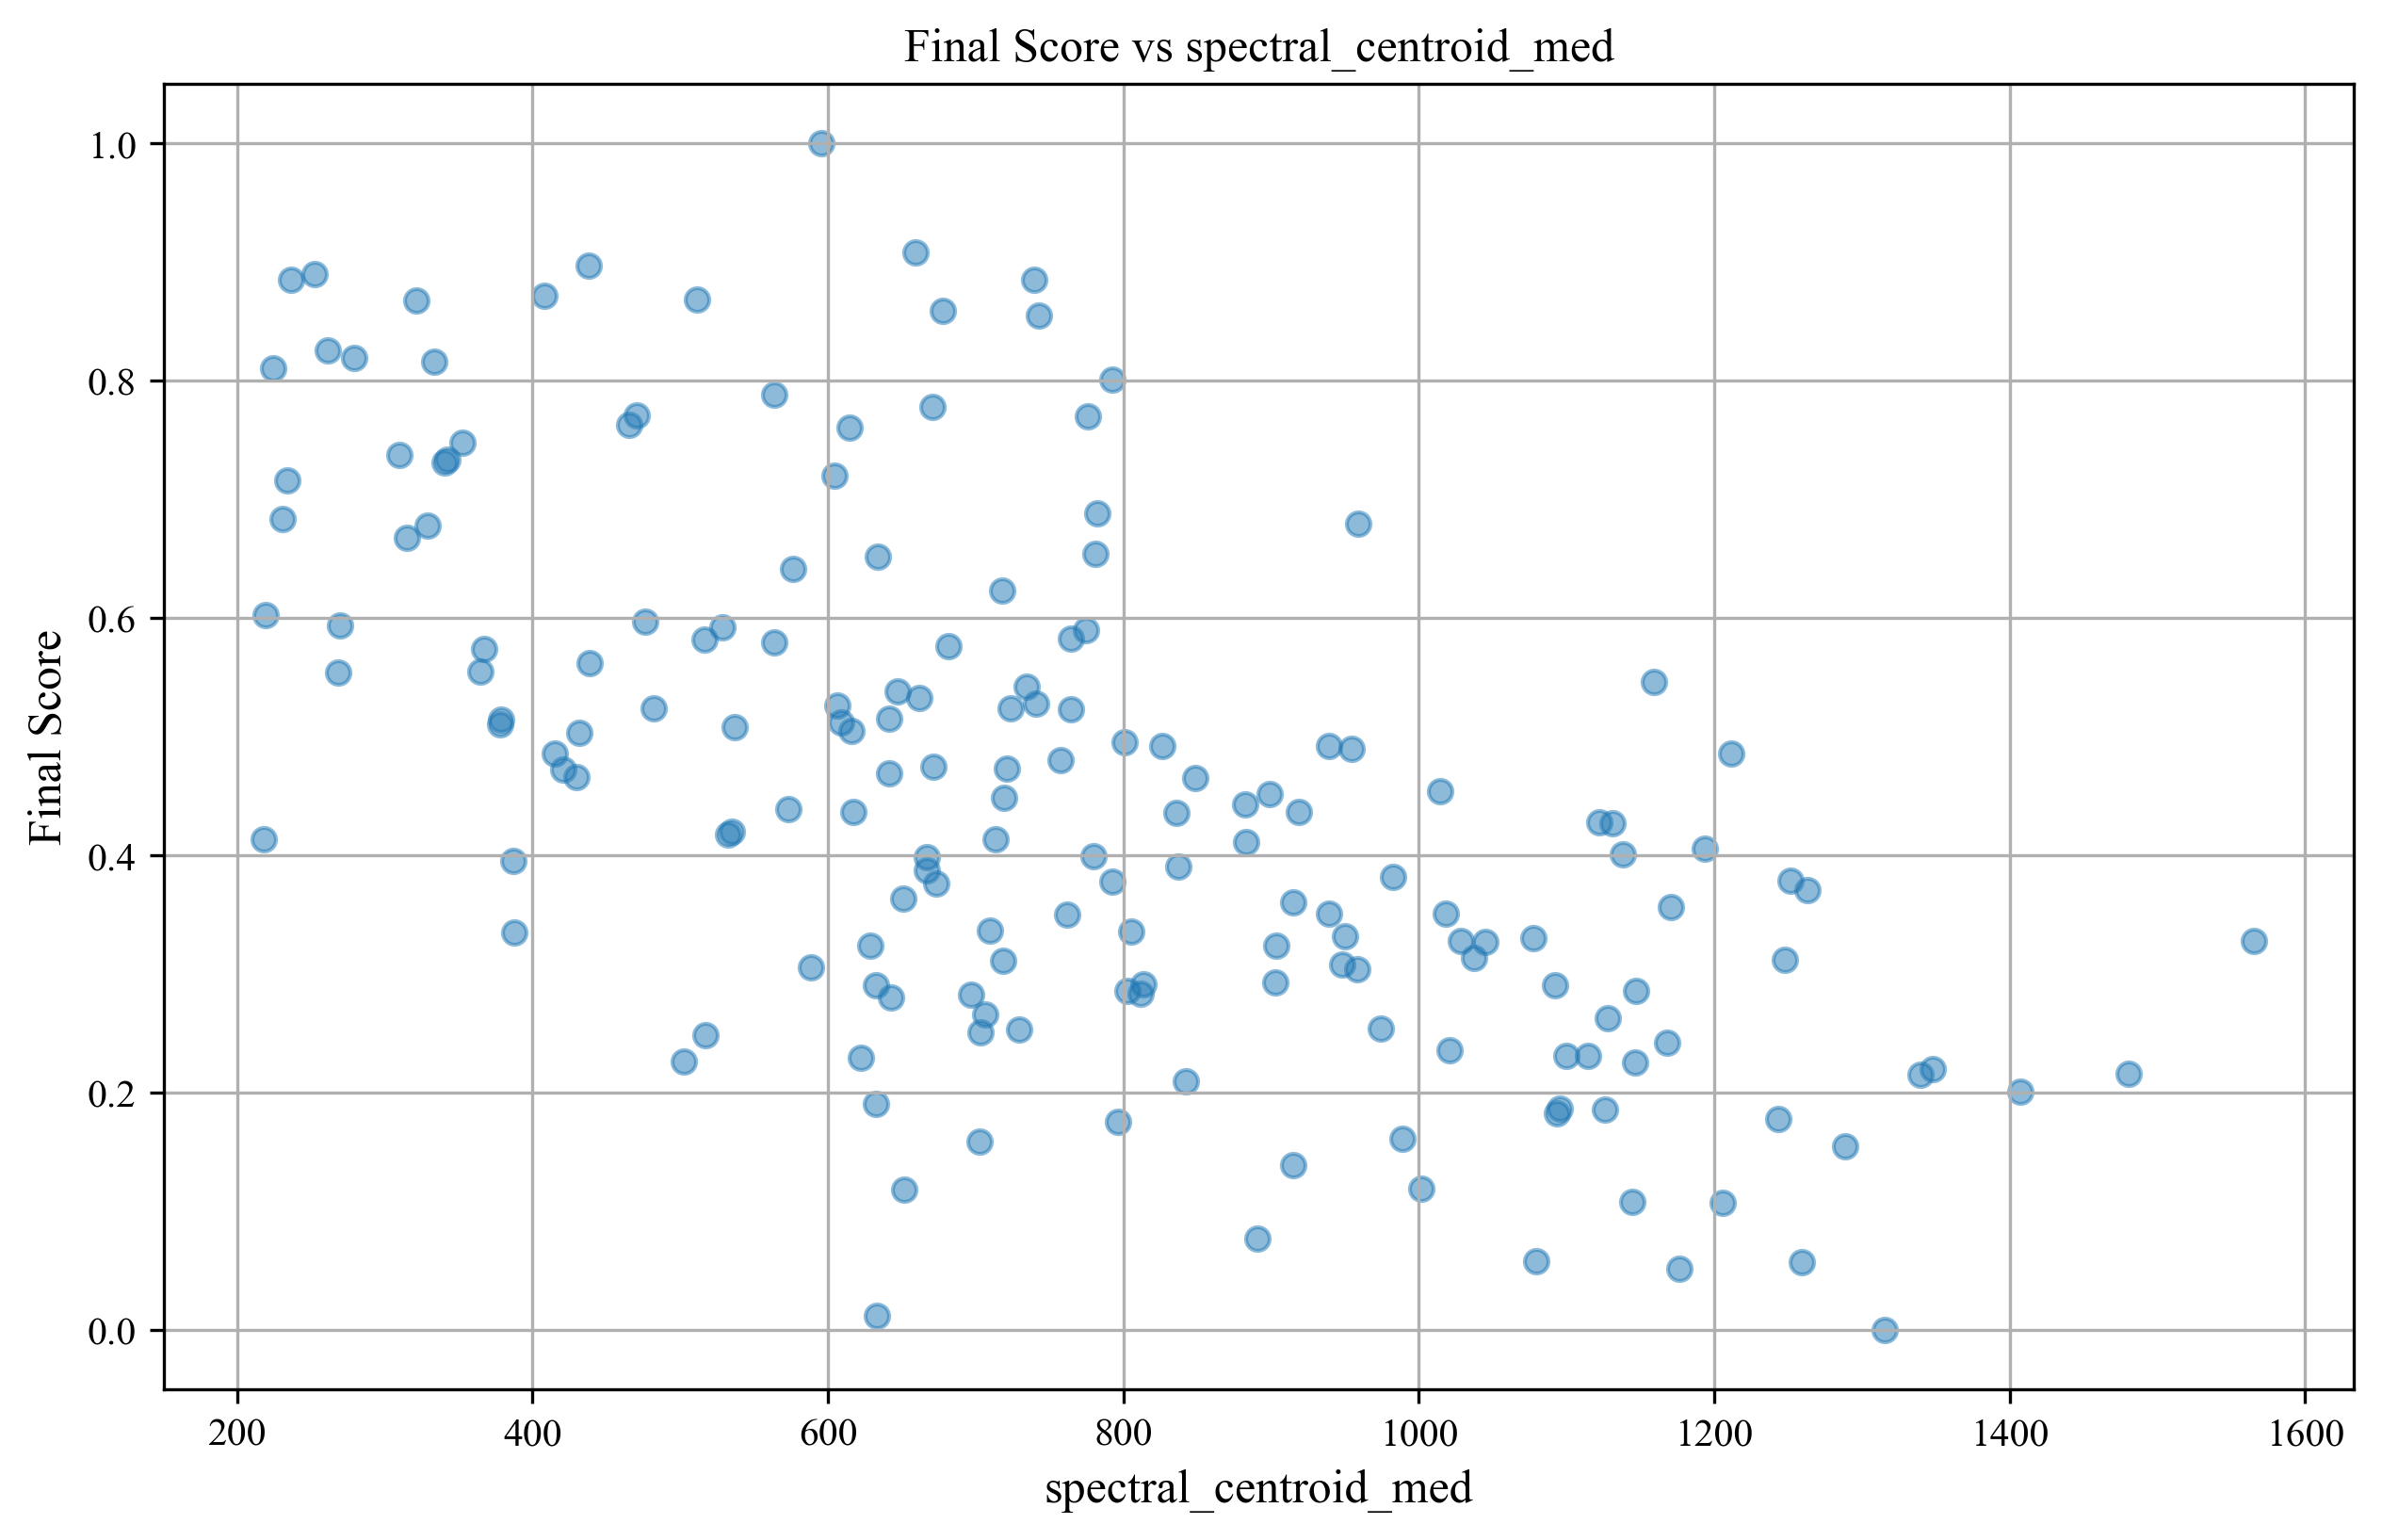

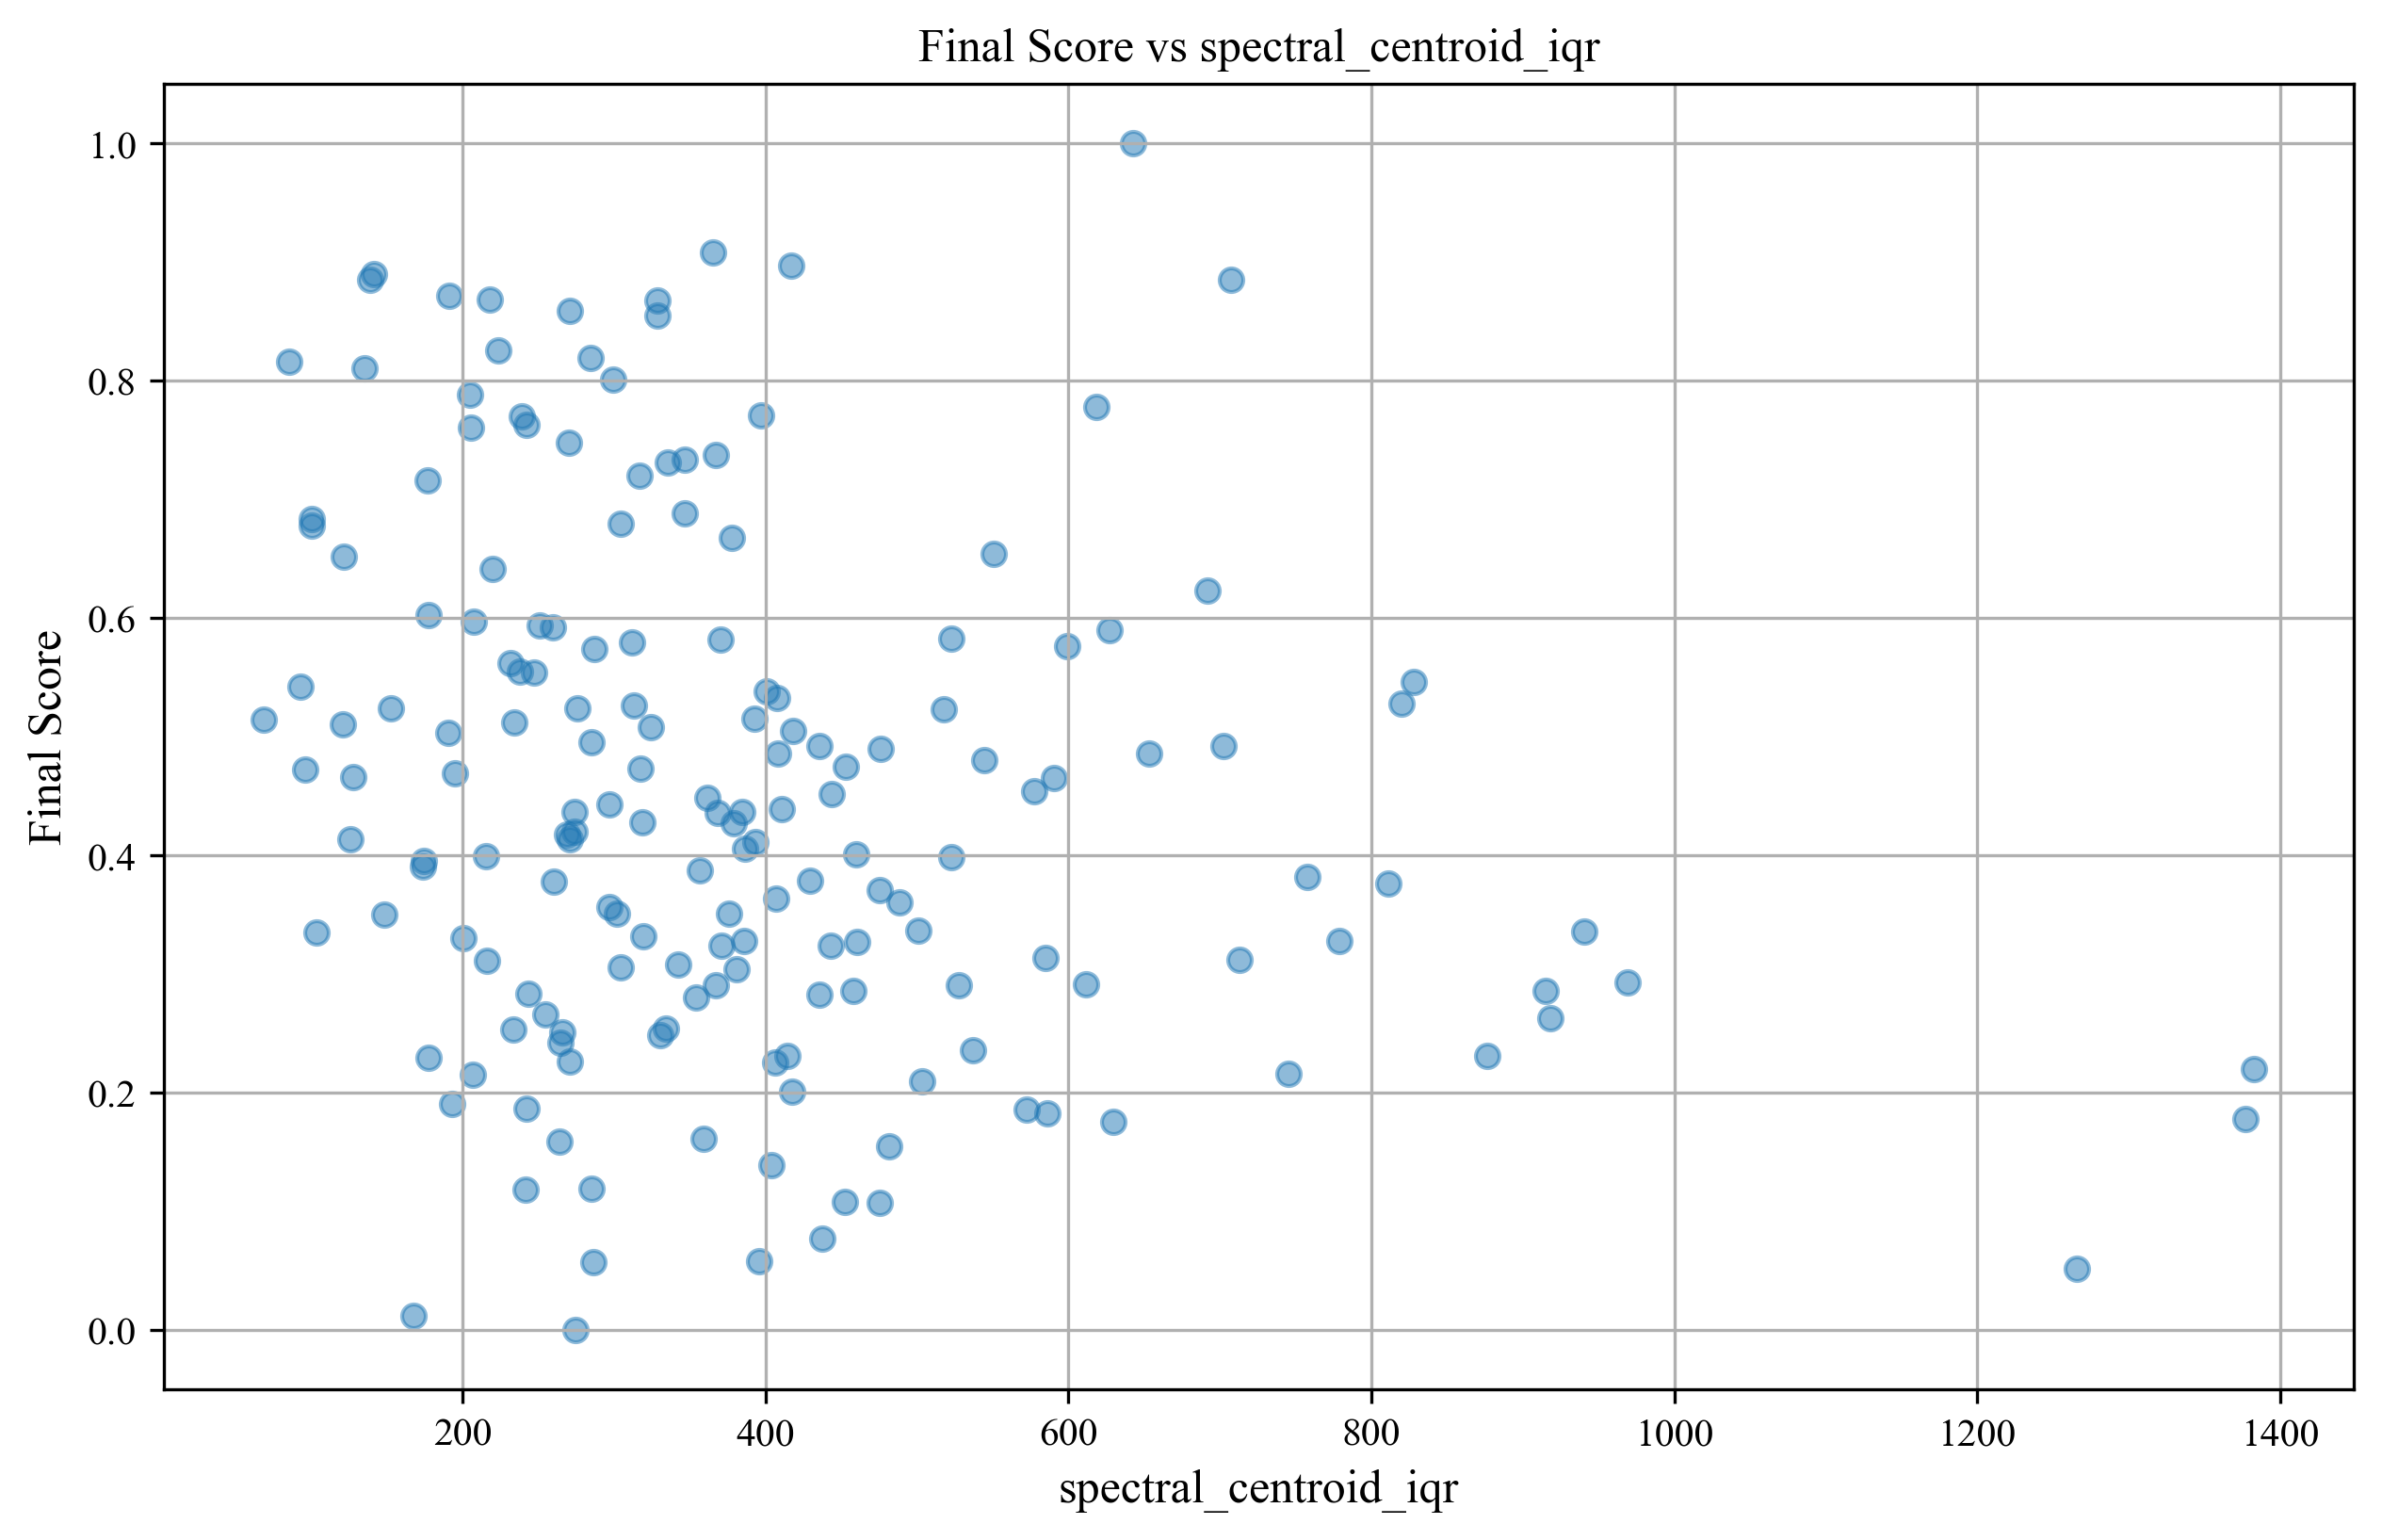

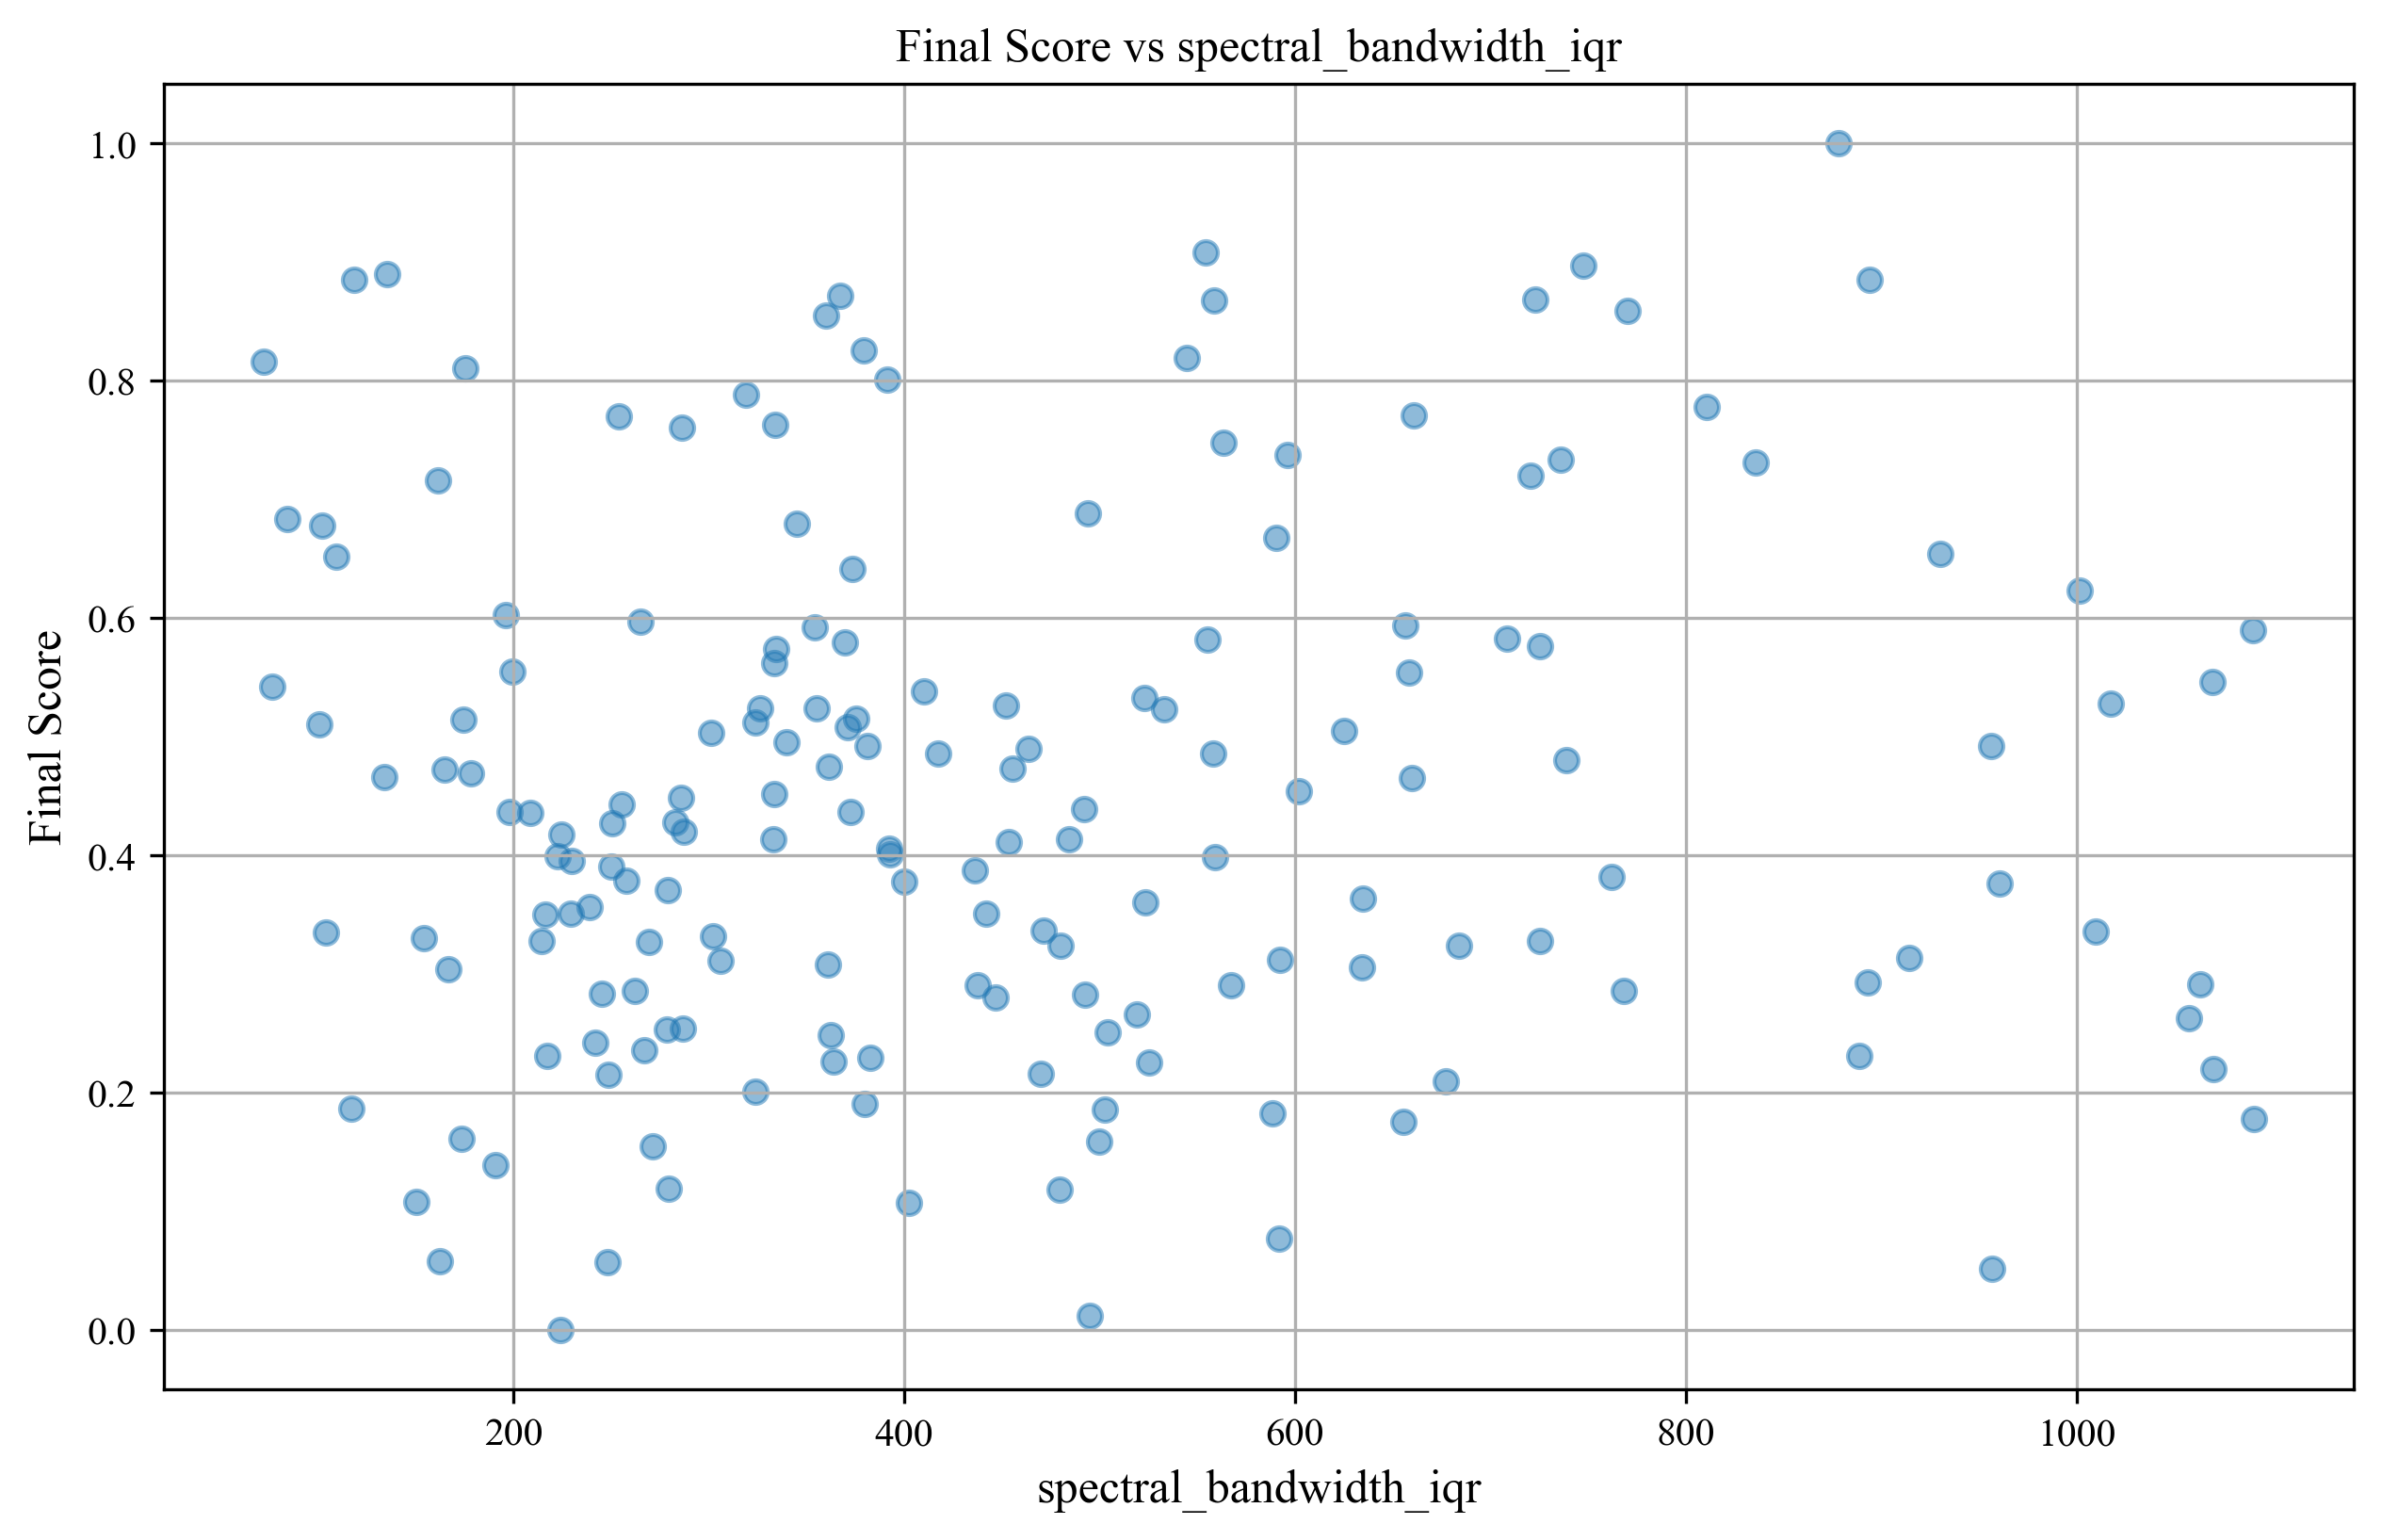

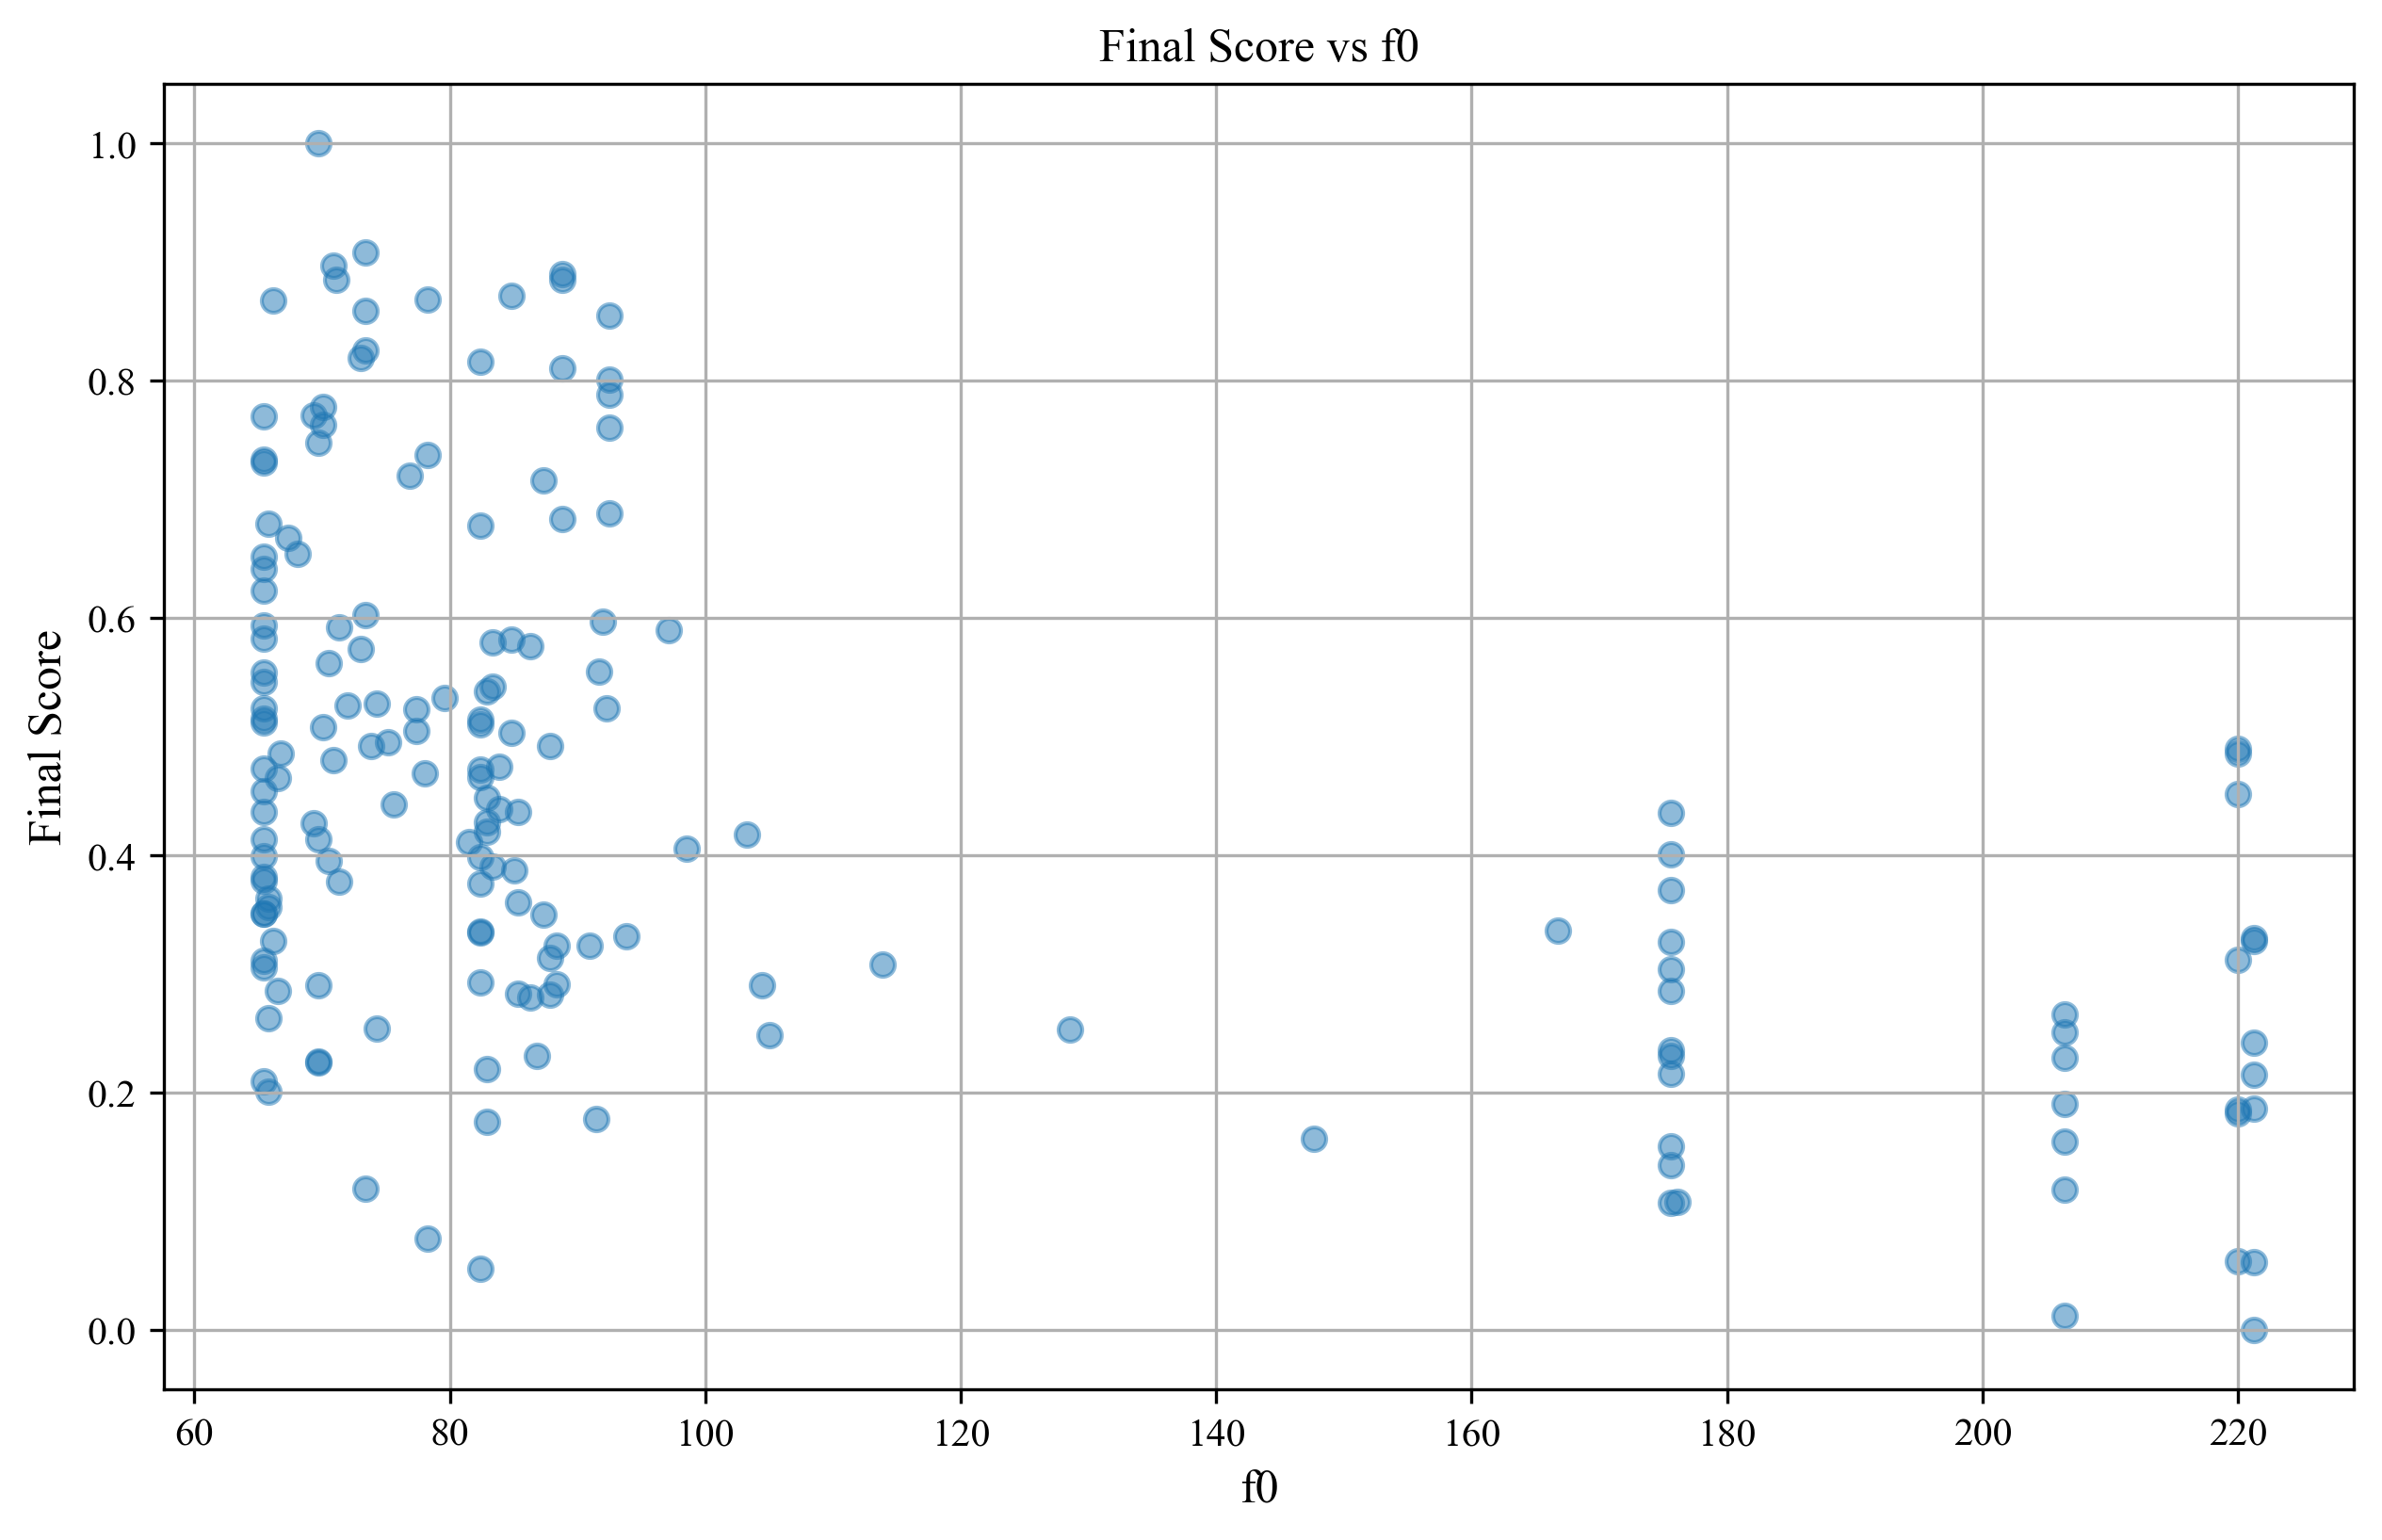

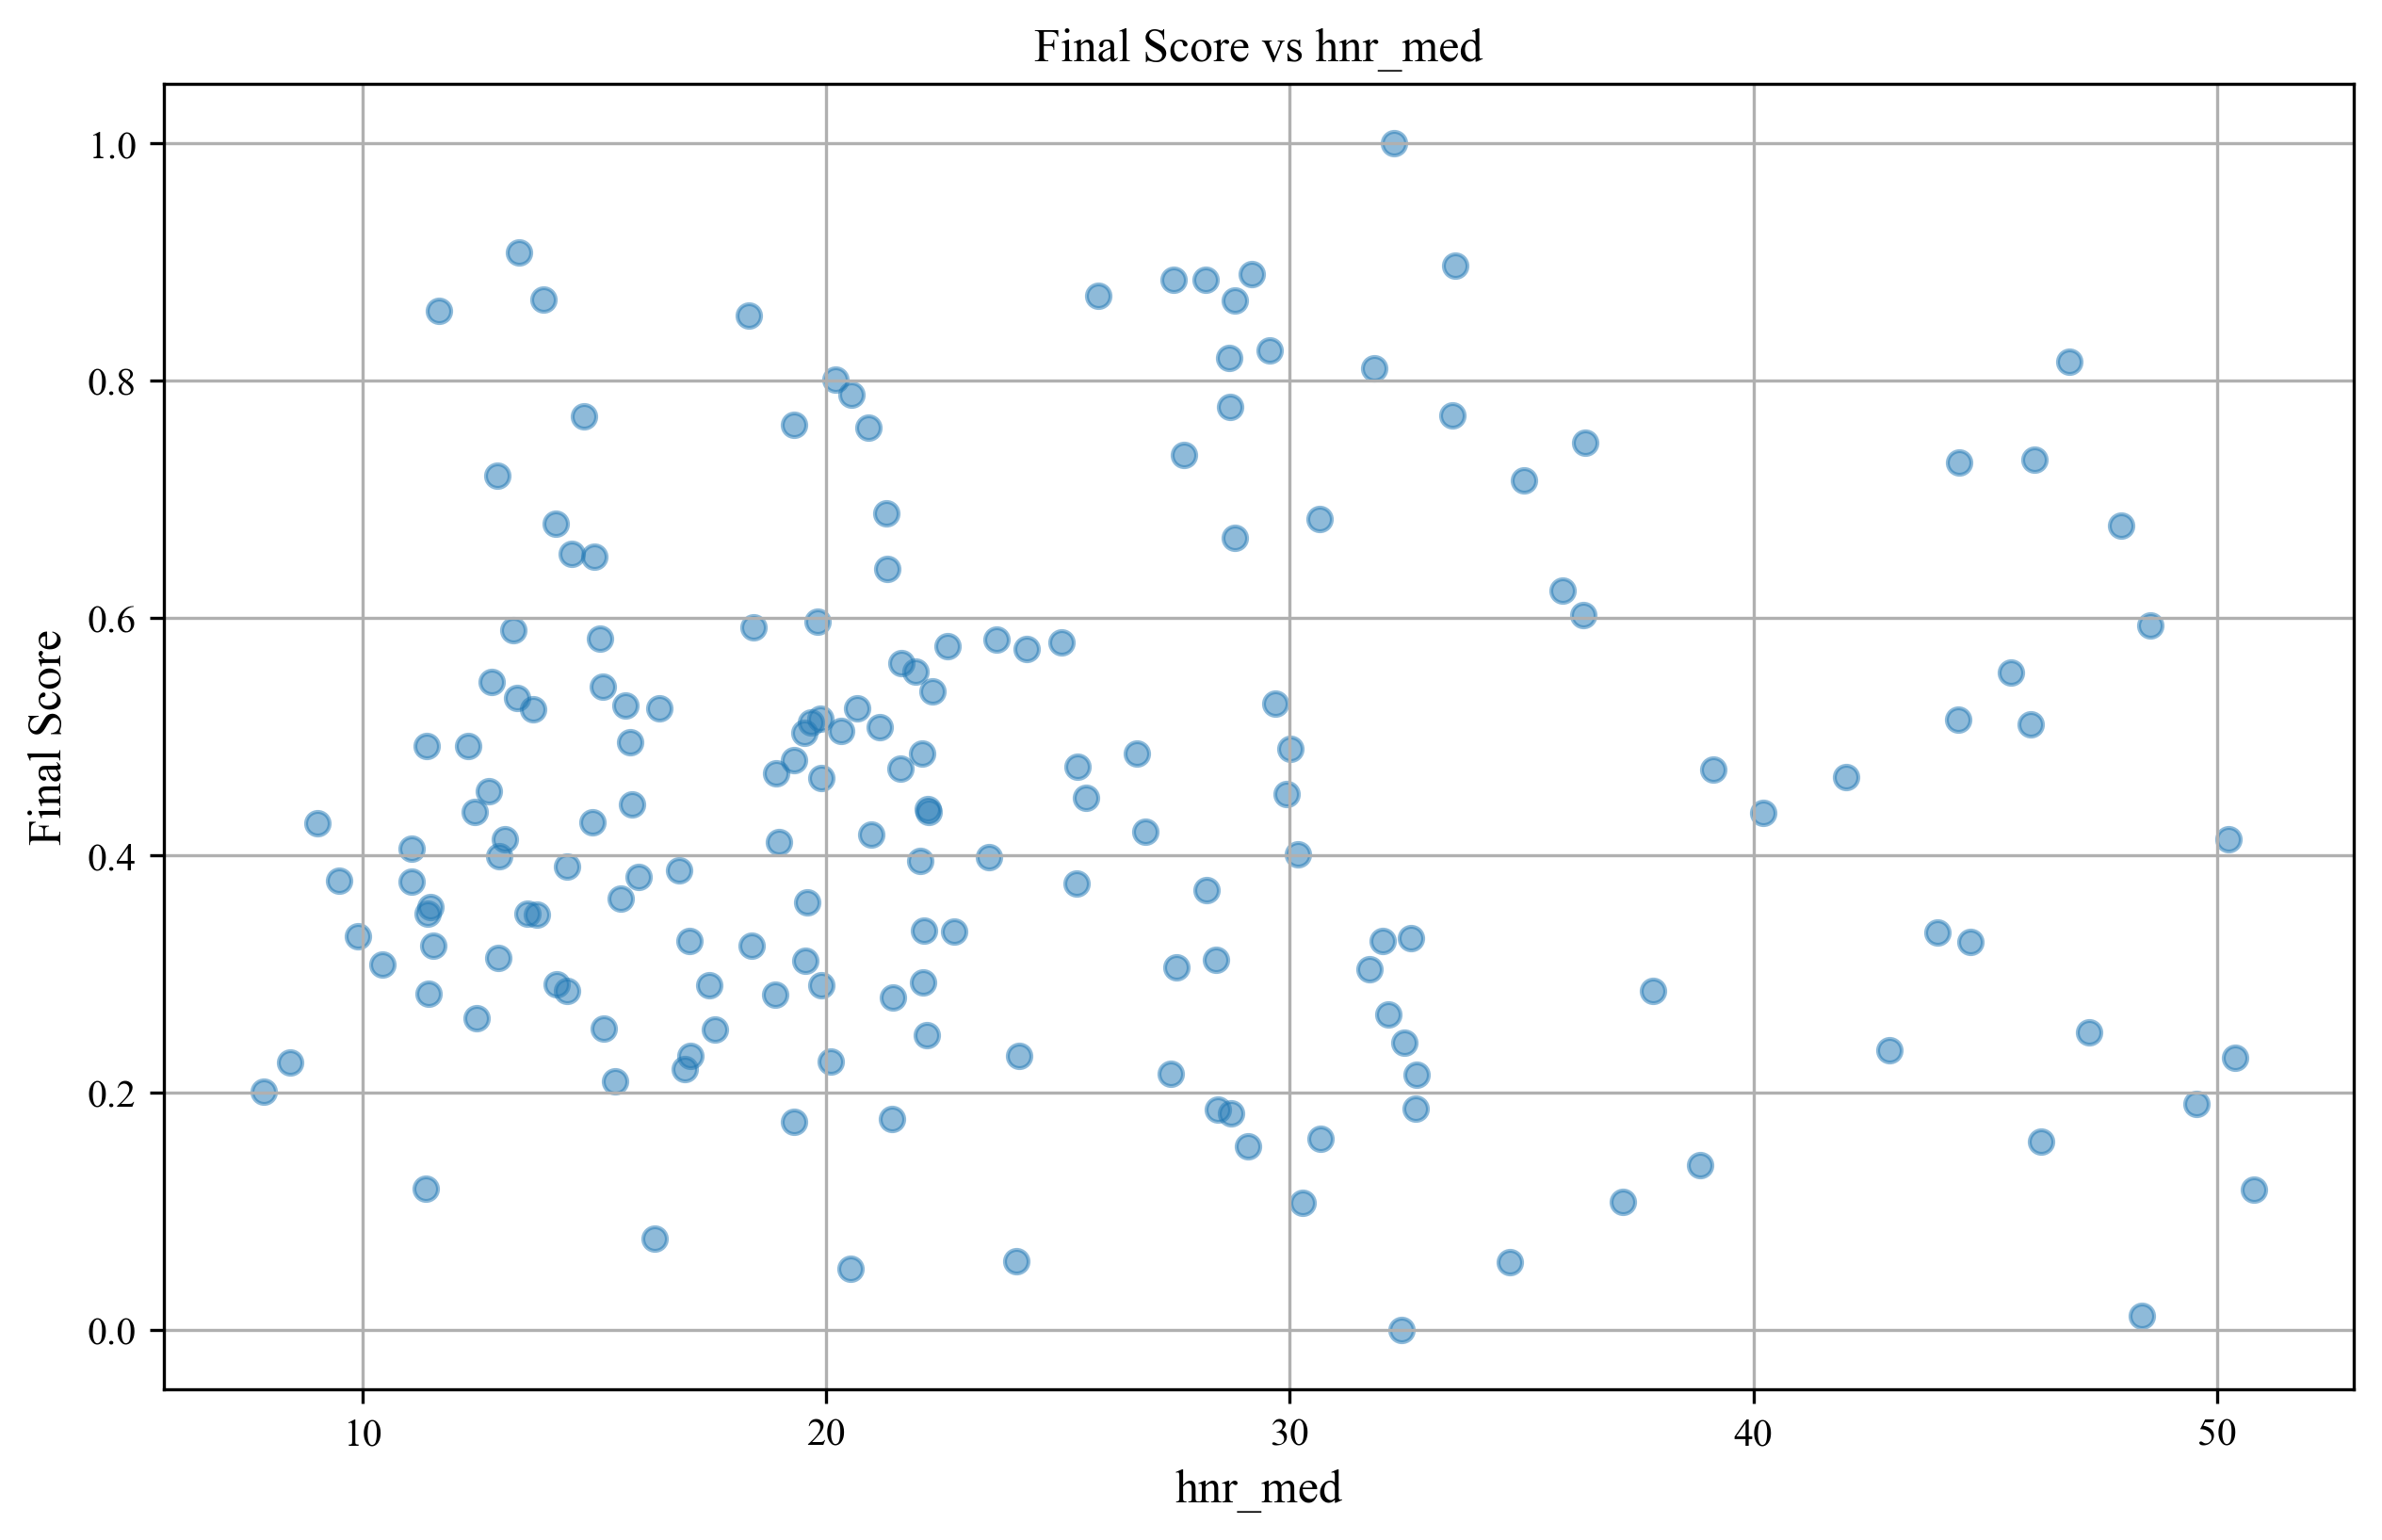

In [ ]:
df_data = pd.concat([X, y], axis=1).sort_values(by="final_score", ascending=False)
for col in feature_columns:
    plt.figure(figsize=(10, 6))
    plt.scatter(df_data[col], df_data["final_score"], alpha=0.5)
    plt.title(f"Final Score vs {col}")
    plt.xlabel(col)
    plt.ylabel("Final Score")
    plt.grid(True)
    plt.show()

In [28]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, explained_variance_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor

# Try importing XGBoost; fall back to GradientBoostingRegressor if unavailable
try:
    import xgboost as xgb
    use_xgb = True
except ImportError:
    from sklearn.ensemble import GradientBoostingRegressor
    use_xgb = False



# ─── 1) LOAD DATA ──────────────────────────────────────────────────
df = pd.read_csv('final_scores_with_features.csv')

target = "final_score"
features = [
    "spectral_centroid_med",
    "spectral_centroid_iqr",
    "spectral_bandwidth_iqr",
    "f0",
    "hnr_med",
]

df = df.dropna(subset=features + [target])

X = df[features]
y = df[target]

y = (y - y.min()) / (y.max() - y.min())  # Normalize final scores to [0, 1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ─── 2) HELPER FOR METRICS ─────────────────────────────────────────
def reg_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        # "ExplainedVar": explained_variance_score(y_true, y_pred),
    }


results = []

# ─── 3) LINEAR REGRESSION (all features) ──────────────────────────
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
results.append({"Model": "LinearRegression (all)", **reg_metrics(y_test, y_pred_lr)})

# ─── 4) LINEAR REGRESSION with RFE (3 best features) ───────────────
from sklearn.feature_selection import RFE

selector = RFE(LinearRegression(), n_features_to_select=3).fit(X_train, y_train)
selected_features = X_train.columns[selector.support_].tolist()

lr_rfe = LinearRegression().fit(X_train[selected_features], y_train)
y_pred_lr_rfe = lr_rfe.predict(X_test[selected_features])
results.append({"Model": "LinearRegression (RFE)", **reg_metrics(y_test, y_pred_lr_rfe)})

# ─── 5) XGBoost / Gradient Boosting ────────────────────────────────
if use_xgb:
    xgb_model = xgb.XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
    )
    xgb_model.fit(X_train, y_train)
    y_pred_xgb = xgb_model.predict(X_test)
    results.append({"Model": "XGBoost", **reg_metrics(y_test, y_pred_xgb)})
    feat_imp = pd.DataFrame(
        {"feature": features, "importance": xgb_model.feature_importances_}
    ).sort_values("importance", ascending=False)
else:
    gbr = GradientBoostingRegressor(random_state=42)
    gbr.fit(X_train, y_train)
    y_pred_xgb = gbr.predict(X_test)
    results.append(
        {"Model": "GradientBoosting", **reg_metrics(y_test, y_pred_xgb)}
    )
    feat_imp = pd.DataFrame(
        {
            "feature": features,
            "importance": gbr.feature_importances_,
        }
    ).sort_values("importance", ascending=False)

# ─── 6) NEURAL NETWORK (MLP) ───────────────────────────────────────
nn_pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "mlp",
            MLPRegressor(
                hidden_layer_sizes=(64, 32),
                activation="relu",
                solver="adam",
                alpha=1e-4,
                learning_rate_init=1e-3,
                max_iter=1000,
                random_state=42,
            ),
        ),
    ]
)
nn_pipeline.fit(X_train, y_train)
y_pred_nn = nn_pipeline.predict(X_test)
results.append({"Model": "NeuralNet", **reg_metrics(y_test, y_pred_nn)})

# ─── 7) DISPLAY RESULTS ────────────────────────────────────────────
results_df = pd.DataFrame(results)
print(results_df)
print("Feature importance (tree model)", feat_imp)


                    Model       MAE      RMSE        R2
0  LinearRegression (all)  0.118695  0.152014  0.481021
1  LinearRegression (RFE)  0.118609  0.152053  0.480753
2                 XGBoost  0.117375  0.153013  0.474180
3               NeuralNet  0.116689  0.162113  0.409777
Feature importance (tree model)                   feature  importance
3                      f0    0.318504
0   spectral_centroid_med    0.281585
4                 hnr_med    0.178286
2  spectral_bandwidth_iqr    0.129220
1   spectral_centroid_iqr    0.092404


In [29]:
# ─── In a new Jupyter cell: extract features via librosa and predict ──────────────────────────
import glob
import os

import numpy as np
import pandas as pd
import librosa

# Make sure lr, lr_rfe, selected_features, xgb_model/gbr, and pipeline_ are already defined

# 1) Find all WAVs under D:\Desktop\Example
audio_paths = glob.glob(r'D:\Desktop\Example\**\*.wav', recursive=True)

# 2) Define feature names
feat_names = [
    "spectral_centroid_med",
    "spectral_centroid_iqr",
    "spectral_bandwidth_iqr",
    "f0",
    "hnr_med",
]

In [30]:

rows = []
for path in audio_paths:
    y, sr = librosa.load(path, sr=None)
    # spectral centroid
    sc = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    sc_med = np.median(sc)
    sc_iqr = np.percentile(sc, 75) - np.percentile(sc, 25)
    # spectral bandwidth
    sbw = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
    sbw_iqr = np.percentile(sbw, 75) - np.percentile(sbw, 25)
    # fundamental freq via PYIN
    f0_vals, voiced, _ = librosa.pyin(y,
                                      fmin=librosa.note_to_hz('C2'),
                                      fmax=librosa.note_to_hz('C7'))
    f0_med = np.nanmedian(f0_vals)
    # approximate HNR: harmonic vs noise energy
    y_harm = librosa.effects.harmonic(y)
    noise = y - y_harm
    hnr = 10 * np.log10(np.sum(y_harm**2) / np.sum(noise**2))

    rows.append({
        "file": os.path.basename(path),
        "spectral_centroid_med": sc_med,
        "spectral_centroid_iqr": sc_iqr,
        "spectral_bandwidth_iqr": sbw_iqr,
        "f0": f0_med,
        "hnr_med": hnr,
    })


In [31]:
feats_df = pd.DataFrame(rows)

In [32]:
feats_df

,file,spectral_centroid_med,spectral_centroid_iqr,spectral_bandwidth_iqr,f0,hnr_med
0,Pop_Fender_Bassman50_Head.wav,858.424731,242.016062,248.157048,66.166377,5.157797
1,Pop_Fender_Bassman50_Head_predicted.wav,792.010566,296.406641,381.833039,65.785287,4.088328
2,Pop_Fender_deluxe_reverb.wav,1202.414160,380.772560,257.245639,65.785287,4.641230
3,Pop_Fender_deluxe_reverb_predicted.wav,1077.995844,450.716414,411.980449,65.785287,3.669237
4,Pop_Marshall_1959Plexi.wav,788.255347,227.332008,246.266677,66.166377,5.698057
5,Pop_Marshall_1959Plexi_predicted.wav,733.714945,304.245010,527.006846,66.166377,5.054886
6,Pop_Marshall_JCM800.wav,1153.955230,337.975751,233.784928,65.785287,4.799898
7,Pop_Marshall_JCM800_predicted.wav,867.759123,312.346720,390.957973,65.785287,4.051954
8,Pop_Orange_Rocker30_Head.wav,954.633067,285.158881,287.696651,65.785287,5.524082
9,Pop_Orange_Rocker30_Head_predicted.wav,856.310966,329.816937,485.471297,66.166377,3.906657


In [ ]:

# ─── 3) LINEAR REGRESSION (all features) ──────────────────────────

y_pred_lr = lr.predict(feats_df[features])

# ─── 5) XGBoost / Gradient Boosting ────────────────────────────────
if use_xgb:
    y_pred_xgb = xgb_model.predict(feats_df[features])



y_pred_nn = nn_pipeline.predict(feats_df[features])

feats_df["pred_lr"] = y_pred_lr
feats_df["pred_xgb"] = y_pred_xgb
feats_df["pred_nn"] = y_pred_nn


In [40]:
feats_df[["file","pred_lr", "pred_xgb", "pred_nn"]]

,file,pred_lr,pred_xgb,pred_nn
0,Pop_Fender_Bassman50_Head.wav,0.437291,0.333711,0.489119
1,Pop_Fender_Bassman50_Head_predicted.wav,0.474989,0.437776,0.517631
2,Pop_Fender_deluxe_reverb.wav,0.302409,0.334027,0.450233
3,Pop_Fender_deluxe_reverb_predicted.wav,0.363382,0.331816,0.476345
4,Pop_Marshall_1959Plexi.wav,0.463881,0.375810,0.506639
5,Pop_Marshall_1959Plexi_predicted.wav,0.509496,0.546620,0.529735
6,Pop_Marshall_JCM800.wav,0.320066,0.346683,0.427715
7,Pop_Marshall_JCM800_predicted.wav,0.446340,0.375809,0.479303
8,Pop_Orange_Rocker30_Head.wav,0.402556,0.153185,0.450506
9,Pop_Orange_Rocker30_Head_predicted.wav,0.459000,0.405218,0.456596


In [114]:
y_pred_nn

array([-0.15234886, -0.13342914, -0.09299106, -0.05018876, -0.15542653,
       -0.04119105,  0.0400002 , -0.00131841,  0.08913043,  0.05862796,
       -0.03340856,  0.03925101,  0.10190102,  0.02050586,  0.02265739,
        0.08799446,  0.09137852,  0.02140024,  0.08547387, -0.17909054,
       -0.03547288, -0.11458363,  0.00823064,  0.19655853, -0.0284458 ,
        0.02433431, -0.04381258, -0.01538823,  0.05436859,  0.03239504,
       -0.02370024,  0.15398531,  0.19219036, -0.01693915, -0.12003683])

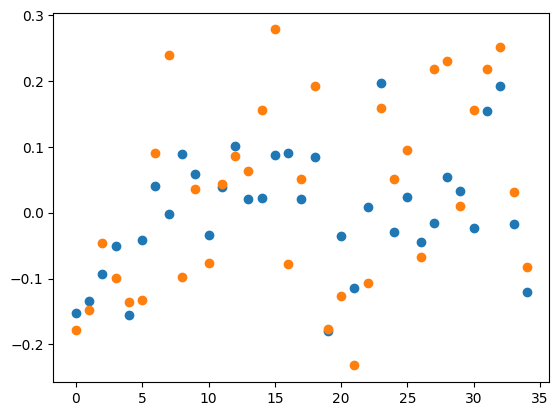

In [115]:
plt.plot(y_pred_nn, 'o', label='Linear Regression')
plt.plot(np.array(y_test), 'o')

In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

# -------------------------------
# SETUP
# -------------------------------
models = {
    'Linear Regression': LinearRegression(),
    'XGBoost': XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, objective='reg:squarederror', random_state=42),
    'Neural Network': MLPRegressor(hidden_layer_sizes=(8, 8), activation='logistic', max_iter=1000, random_state=42)
}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
results_all_models = []

# -------------------------------
# CROSS VALIDATION
# -------------------------------
for model_name, model in models.items():
    print(f"\n=== {model_name} ===")
    fold_metrics = []
    
    for fold, (train_index, val_index) in enumerate(kfold.split(X_train), start=1):
        X_train_cv, X_val_cv = X_train.iloc[train_index], X_train.iloc[val_index]
        y_train_cv, y_val_cv = y_train.iloc[train_index], y_train.iloc[val_index]

        model.fit(X_train_cv, y_train_cv)
        y_pred_val = model.predict(X_val_cv)

        mse = mean_squared_error(y_val_cv, y_pred_val)
        mae = mean_absolute_error(y_val_cv, y_pred_val)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_val_cv, y_pred_val)

        fold_metrics.append({
            'Model': model_name,
            'Fold': fold,
            'MSE': mse,
            'RMSE': rmse,
            'MAE': mae,
            'R2': r2
        })

        print(f"Fold {fold}: MSE: {mse:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")
    
    results_all_models.extend(fold_metrics)

# -------------------------------
# RESULTS
# -------------------------------
df_results = pd.DataFrame(results_all_models)
mean_results = df_results.groupby("Model").mean().reset_index()
print("\n=== Mean Metrics Across Folds ===")
print(mean_results)



=== Linear Regression ===
Fold 1: MSE: 0.0126, RMSE: 0.1123, MAE: 0.0919, R2: 0.0182
Fold 2: MSE: 0.0150, RMSE: 0.1226, MAE: 0.0924, R2: 0.1199
Fold 3: MSE: 0.0140, RMSE: 0.1182, MAE: 0.0939, R2: 0.2723
Fold 4: MSE: 0.0117, RMSE: 0.1080, MAE: 0.0832, R2: 0.5325
Fold 5: MSE: 0.0229, RMSE: 0.1513, MAE: 0.1269, R2: 0.2658

=== XGBoost ===
Fold 1: MSE: 0.0100, RMSE: 0.0998, MAE: 0.0836, R2: 0.2242
Fold 2: MSE: 0.0106, RMSE: 0.1031, MAE: 0.0843, R2: 0.3781
Fold 3: MSE: 0.0096, RMSE: 0.0979, MAE: 0.0778, R2: 0.5009
Fold 4: MSE: 0.0097, RMSE: 0.0983, MAE: 0.0851, R2: 0.6122
Fold 5: MSE: 0.0218, RMSE: 0.1478, MAE: 0.1234, R2: 0.2993

=== Neural Network ===
Fold 1: MSE: 0.0156, RMSE: 0.1250, MAE: 0.1012, R2: -0.2172
Fold 2: MSE: 0.0174, RMSE: 0.1321, MAE: 0.1018, R2: -0.0217
Fold 3: MSE: 0.0157, RMSE: 0.1251, MAE: 0.1011, R2: 0.1849
Fold 4: MSE: 0.0214, RMSE: 0.1462, MAE: 0.1132, R2: 0.1429
Fold 5: MSE: 0.0289, RMSE: 0.1700, MAE: 0.1390, R2: 0.0723

=== Mean Metrics Across Folds ===
          

In [117]:
y_mean = np.full_like(y_test, 0.5)
print("Baseline RMSE:", np.sqrt(mean_squared_error(y_test, y_mean)))


Baseline RMSE: 0.49600976581440925


In [118]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred_test, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("True"); plt.ylabel("Predicted"); plt.title("Prediction vs Truth"); plt.show()


NameError: name 'y_pred_test' is not defined